In [9]:
import pandas as pd

# Tus archivos están en la carpeta raíz
files = ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']

for file in files:
    try:
        df = pd.read_csv(file)
        print(f"--- Columnas en {file} ---")
        print(df.columns.tolist())
        print("\n")
    except FileNotFoundError:
        print(f"No se encontró el archivo {file}")

--- Columnas en 2015.csv ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']


--- Columnas en 2016.csv ---
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']


--- Columnas en 2017.csv ---
['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']


--- Columnas en 2018.csv ---
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions 

In [10]:
# Ver si hay celdas vacías (Nulos)
print("--- Valores nulos por archivo ---")
for file in files:
    df = pd.read_csv(file)
    print(f"{file}: {df.isnull().sum().sum()} valores nulos encontrados")

# Ver si las columnas tienen el formato correcto (ej. números leídos como texto)
# Ejecuta esto en uno de los archivos para verificar
print("\n--- Tipos de datos (2019.csv) ---")
df_2019 = pd.read_csv('2019.csv')
print(df_2019.dtypes)

--- Valores nulos por archivo ---
2015.csv: 0 valores nulos encontrados
2016.csv: 0 valores nulos encontrados
2017.csv: 0 valores nulos encontrados
2018.csv: 1 valores nulos encontrados
2019.csv: 0 valores nulos encontrados

--- Tipos de datos (2019.csv) ---
Overall rank                      int64
Country or region                   str
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


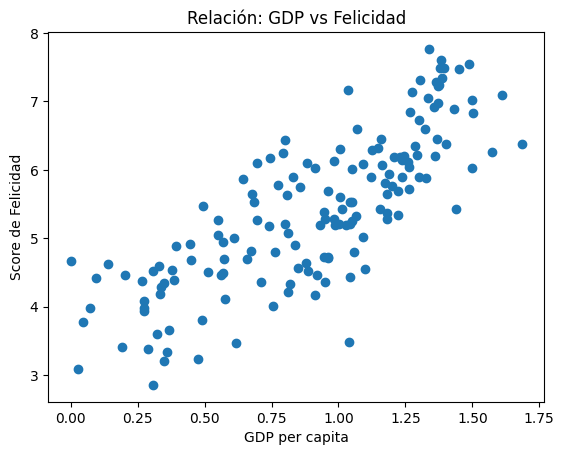

In [12]:
import matplotlib.pyplot as plt

# Esto ayuda a justificar por qué usas esas columnas para el modelo
plt.scatter(df_2019['GDP per capita'], df_2019['Score'])
plt.title('Relación: GDP vs Felicidad')
plt.xlabel('GDP per capita')
plt.ylabel('Score de Felicidad')
plt.show()

In [15]:
import pandas as pd

def limpiar_y_unificar():
    data_list = []
    files = ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']
    
    # Mapeo de nombres para estandarizar: {NombreOriginal: NombreFinal}
    # Ajusta esto según lo que viste en tu EDA
    mapeo = {
        'Happiness Score': 'happiness_score', 'Score': 'happiness_score', 'Happiness.Score': 'happiness_score',
        'Economy (GDP per Capita)': 'gdp', 'GDP per capita': 'gdp', 'Economy..GDP.per.Capita.': 'gdp',
        'Country': 'country', 'Country or region': 'country'
    }

    for file in files:
        df = pd.read_csv(file)
        
        # 1. Renombrar columnas para que coincidan
        df = df.rename(columns=mapeo)
        
        # 2. Agregar columna del año para saber de dónde viene el dato
        year = file.replace('.csv', '')
        df['year'] = year
        
        # 3. Guardar en la lista
        data_list.append(df)
        print(f"Procesado {file}: {df.shape[0]} filas.")
    
    # 4. Unir todo
    df_final = pd.concat(data_list, ignore_index=True)
    df_final.to_csv('data_final.csv', index=False)
    print("\n¡Éxito! Archivo 'data_final.csv' creado.")

limpiar_y_unificar()

Procesado 2015.csv: 158 filas.
Procesado 2016.csv: 157 filas.
Procesado 2017.csv: 155 filas.
Procesado 2018.csv: 156 filas.
Procesado 2019.csv: 156 filas.

¡Éxito! Archivo 'data_final.csv' creado.


In [17]:
import pandas as pd
df = pd.read_csv('data_final.csv')
print(df.columns.tolist())

['country', 'Region', 'Happiness Rank', 'happiness_score', 'Standard Error', 'gdp', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'year', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Happiness.Rank', 'Whisker.high', 'Whisker.low', 'Health..Life.Expectancy.', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Overall rank', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Perceptions of corruption']


In [19]:
import pandas as pd
df = pd.read_csv('data_final.csv')
print("--- NOMBRES EXACTOS EN TU ARCHIVO ---")
print(df.columns.tolist())


--- NOMBRES EXACTOS EN TU ARCHIVO ---
['country', 'Region', 'Happiness Rank', 'happiness_score', 'Standard Error', 'gdp', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual', 'year', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Happiness.Rank', 'Whisker.high', 'Whisker.low', 'Health..Life.Expectancy.', 'Trust..Government.Corruption.', 'Dystopia.Residual', 'Overall rank', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Perceptions of corruption']


In [ ]:
import pandas as pd

def preparar_datos():
    files = ['2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv']
    data_list = []
    
    for file in files:
        df = pd.read_csv(file)
        # Estandarizamos nombres usando lo que vimos en tu lista
        # Renombramos columnas clave para que coincidan entre años
        df = df.rename(columns={
            'Happiness Score': 'happiness_score', 'Score': 'happiness_score', 'Happiness.Score': 'happiness_score',
            'Economy (GDP per Capita)': 'gdp', 'Economy..GDP.per.Capita.': 'gdp', 'GDP per capita': 'gdp',
            'Family': 'family', 'Social support': 'family',
            'Freedom': 'freedom', 'Freedom to make life choices': 'freedom'
        })
        # Nos quedamos solo con las que existen y nos sirven
        columnas_base = ['happiness_score', 'gdp', 'family', 'freedom']
        # Filtramos solo las que están en el dataframe actual
        df_limpio = df[[c for c in columnas_base if c in df.columns]]
        df_limpio['year'] = file.replace('.csv', '')
        data_list.append(df_limpio)
    
    df_final = pd.concat(data_list, ignore_index=True)
    df_final.to_csv('data_final_limpio.csv', index=False)
    print("Archivo 'data_final_limpio.csv' creado con éxito.")

preparar_datos()